In [ ]:
# Notebook to visualize the process of training 

In [ ]:
import argparse
import random
import time
from pathlib import Path
from types import SimpleNamespace

import cv2
import numpy as np
import pandas as pd
import pydicom
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm

from ultralytics.nn.modules import Detect
from ultralytics.utils.loss import v8DetectionLoss

import matplotlib.pyplot as plt

from mammo_prep.io import load_dicom
from mammo_prep.windowing import preprocess_window
from mammo_prep.artifacts import (
    flip_to_standard,
    crop_breast,
    resize_long_side,
    pad_to_square,
)


In [12]:
# Variables 

ANNOTATIONS_CSV = Path(
    "/home/enric/Datasets/Original/vindr/finding_annotations.csv"
)

IMAGES = Path(
    "/home/enric/Datasets/Original/vindr/images"
)

DATASET_SPLIT = Path(
    "/home/enric/Mammo/Lesion Detection/Yolo v8/vindr_yolo"
)

OUTPUT_DIR = Path(
    "/home/enric/Mammo/Lesion Detection/Yolo v8/vindr_yolo_swin/train_v2_1"
)




TARGET_SIZE= 1024


In [13]:
# Import Annotations CSV 

annotations = pd.read_csv(ANNOTATIONS_CSV)
df=annotations # per practicitat més endavant
df.head()

sample_images = df[df["xmin"].notna()][['study_id','image_id']].drop_duplicates().sample(1, random_state=42)


In [14]:
sample_images

,study_id,image_id
1128,9c8e8f688e99a35f6bb0a78cd4ae8d7e,9f65a2368a5df60f1910d687067ced3b


preprocessing sample images...


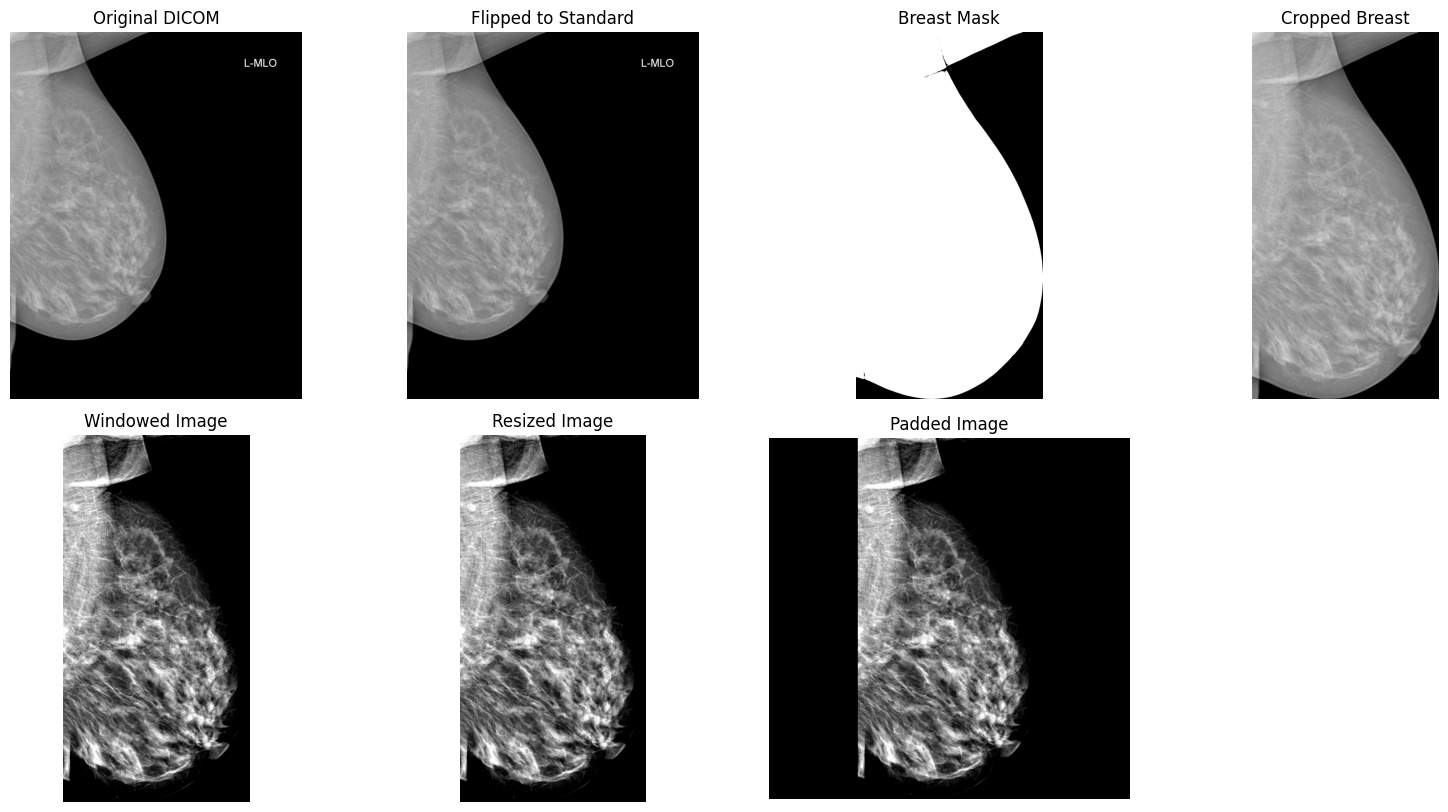

In [34]:
# DICOM PREPROCESSING

def preprocess_dicom(dicom_path):
    img, ds = load_dicom(dicom_path)
    img_flip = flip_to_standard(img, ds)

    img_crop, mask = crop_breast(img_flip)   # ajusta-ho si crop_breast retorna només la imatge

    # Si el crop és degenerat (màscara fallida), usa la imatge sense retallar
    h, w = img_crop.shape[:2]
    if min(h, w) < 0.1 * max(h, w):
        print(f"[WARN] Crop degenerat {img_crop.shape} a {dicom_path}; uso img_flip")
        img_crop = img_flip

    img_windowed = preprocess_window(
        img_crop,
        dicom_dataset=ds,
        method="breast_tissue",
        voi_func="LINEAR",
        output_dtype=np.uint8,
    )
    img_windowed = np.asarray(img_windowed)

    if img_windowed.ndim == 3:
        img_windowed = img_windowed[..., 0]

    if img_windowed.ndim != 2 or 0 in img_windowed.shape:
        raise ValueError(f"img_windowed té shape invàlid: {img_windowed.shape}")

    # Resize robust (no depèn de resize_long_side)
    h, w = img_windowed.shape
    scale = TARGET_SIZE / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    img_resized = cv2.resize(img_windowed, (new_w, new_h), interpolation=cv2.INTER_AREA)

    img_padded = pad_to_square(img_resized)

    return img, img_flip, mask, img_crop, img_windowed, img_resized, img_padded


print("preprocessing sample images...")
plt.figure(figsize=(20, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.1)
for i, (study_id, image_id) in enumerate(sample_images.values):
    dicom_path = IMAGES / study_id / f"{image_id}.dicom"
    img, img_flip, mask, img_crop, img_windowed, img_resized, img_padded = preprocess_dicom(dicom_path)

    plt.subplot(2, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original DICOM")
    plt.axis('off')

    plt.subplot(2, 4, 2)
    plt.imshow(img_flip, cmap='gray')
    plt.title("Flipped to Standard")
    plt.axis('off')

    plt.subplot(2, 4, 3)
    plt.imshow(mask, cmap='gray')
    plt.title("Breast Mask")
    plt.axis('off')

    plt.subplot(2, 4, 4)
    plt.imshow(img_crop, cmap='gray')
    plt.title("Cropped Breast")
    plt.axis('off')

    plt.subplot(2, 4, 5)
    plt.imshow(img_windowed, cmap='gray')
    plt.title("Windowed Image")
    plt.axis('off')

    plt.subplot(2, 4, 6)
    plt.imshow(img_resized, cmap='gray')
    plt.title("Resized Image")
    plt.axis('off')

    plt.subplot(2, 4, 7)
    plt.imshow(img_padded, cmap='gray')
    plt.title("Padded Image")
    plt.axis('off')


In [ ]:
print(IMAGES)

dicom_path = IMAGES / study_id / f"{image_id}.dicom"
print(dicom_path)

# Ejemplo esperado:
# /home/enric/Datasets/Original/vindr/images/<study_id>/<image_id>.dicom

/home/enric/Datasets/Original/vindr/images
/home/enric/Datasets/Original/vindr/images/9c8e8f688e99a35f6bb0a78cd4ae8d7e/9f65a2368a5df60f1910d687067ced3b.dcm


In [ ]:
# TRANSFORM BOXES TO ROI 

def bbox_from_mask(mask):
    """Obtiene el bounding box (x1, y1, x2, y2) de la máscara de mama."""
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return 0, 0, mask.shape[1], mask.shape[0]
    x1, x2 = xs.min(), xs.max() + 1
    y1, y2 = ys.min(), ys.max() + 1
    return int(x1), int(y1), int(x2), int(y2)


def transform_boxes_to_roi(labels, original_width, original_height, roi_x1, roi_y1, roi_x2, roi_y2):
    """
    labels: np.ndarray Nx5 en formato YOLO [cls, cx, cy, w, h] normalizado a imagen original.
    Devuelve labels Nx5 normalizados al ROI.
    """
    roi_w = roi_x2 - roi_x1
    roi_h = roi_y2 - roi_y1

    transformed = []

    for cls_id, cx, cy, bw, bh in labels:
        # YOLO normalizado -> píxeles absolutos en imagen original
        x_center = cx * original_width
        y_center = cy * original_height
        box_w = bw * original_width
        box_h = bh * original_height

        x_min = x_center - box_w / 2.0
        y_min = y_center - box_h / 2.0
        x_max = x_center + box_w / 2.0
        y_max = y_center + box_h / 2.0

        # Traslada al sistema de coordenadas del ROI
        x_min -= roi_x1
        x_max -= roi_x1
        y_min -= roi_y1
        y_max -= roi_y1

        # Clip al ROI
        x_min = np.clip(x_min, 0, roi_w)
        x_max = np.clip(x_max, 0, roi_w)
        y_min = np.clip(y_min, 0, roi_h)
        y_max = np.clip(y_max, 0, roi_h)

        new_w = x_max - x_min
        new_h = y_max - y_min
        if new_w <= 1 or new_h <= 1:
            continue

        new_cx = (x_min + x_max) / 2.0
        new_cy = (y_min + y_max) / 2.0

        transformed.append([
            cls_id,
            new_cx / roi_w,
            new_cy / roi_h,
            new_w / roi_w,
            new_h / roi_h,
        ])

    if not transformed:
        return np.zeros((0, 5), dtype=np.float32)

    return np.asarray(transformed, dtype=np.float32)


def row_to_yolo_labels(row, image_w, image_h):
    """Construye un array Nx5 desde xmin,ymin,xmax,ymax (si existen) para una imagen."""
    rows = row if isinstance(row, pd.DataFrame) else pd.DataFrame([row])
    labels = []
    for _, r in rows.iterrows():
        if pd.isna(r.get("xmin")) or pd.isna(r.get("ymin")) or pd.isna(r.get("xmax")) or pd.isna(r.get("ymax")):
            continue
        xmin, ymin = float(r["xmin"]), float(r["ymin"]), float(r["xmax"]), float(r["ymax"])
        cx = ((xmin + xmax) / 2.0) / image_w
        cy = ((ymin + ymax) / 2.0) / image_h
        bw = (xmax - xmin) / image_w
        bh = (ymax - ymin) / image_h
        labels.append([0, cx, cy, bw, bh])  # clase 0: lesión
    if not labels:
        return np.zeros((0, 5), dtype=np.float32)
    return np.asarray(labels, dtype=np.float32)


def demo_transform_boxes_to_roi(df, sample_images, images_root):
    study_id, image_id = sample_images.iloc[0]["study_id"], sample_images.iloc[0]["image_id"]
    dicom_path = images_root / study_id / f"{image_id}.dicom"

    img, img_flip, mask, img_crop, img_windowed, img_resized, img_padded = preprocess_dicom(dicom_path)
    h, w = img_flip.shape[:2]

    roi_x1, roi_y1, roi_x2, roi_y2 = bbox_from_mask(mask)
    labels = row_to_yolo_labels(
        df[(df["study_id"] == study_id) & (df["image_id"] == image_id)],
        image_w=w,
        image_h=h,
    )

    labels_roi = transform_boxes_to_roi(
        labels, w, h,
        roi_x1, roi_y1, roi_x2, roi_y2
    )

    print(f"image_id: {image_id}")
    print(f"ROI: x1={roi_x1}, y1={roi_y1}, x2={roi_x2}, y2={roi_y2}")
    print(f"boxes originales: {labels.shape[0]}")
    print(f"boxes en ROI: {labels_roi.shape[0]}")
    print("labels_roi (YOLO normalizado a ROI):")
    print(labels_roi)

    return labels, labels_roi


labels_orig, labels_roi = demo_transform_boxes_to_roi(df, sample_images, IMAGES)

In [ ]:
# VISUALIZAR CADA PASO (imagen + cajas)

def yolo_to_xyxy_pixels(labels, img_w, img_h):
    """Convierte Nx5 YOLO [cls,cx,cy,w,h] normalizado -> Nx5 [cls,xmin,ymin,xmax,ymax] en píxeles."""
    out = []
    for cls_id, cx, cy, bw, bh in labels:
        x_center = cx * img_w
        y_center = cy * img_h
        box_w = bw * img_w
        box_h = bh * img_h

        xmin = x_center - box_w / 2.0
        ymin = y_center - box_h / 2.0
        xmax = x_center + box_w / 2.0
        ymax = y_center + box_h / 2.0
        out.append([cls_id, xmin, ymin, xmax, ymax])

    if not out:
        return np.zeros((0, 5), dtype=np.float32)
    return np.asarray(out, dtype=np.float32)


def draw_xyxy(ax, image, boxes_xyxy, color='lime', title=''):
    ax.imshow(image, cmap='gray' if image.ndim == 2 else None)
    for b in boxes_xyxy:
        _, xmin, ymin, xmax, ymax = b
        w = max(1.0, xmax - xmin)
        h = max(1.0, ymax - ymin)
        rect = plt.Rectangle((xmin, ymin), w, h, fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
    ax.set_title(title)
    ax.axis('off')


def visualize_transform_step_by_step(df, sample_images, images_root):
    study_id = sample_images.iloc[0]['study_id']
    image_id = sample_images.iloc[0]['image_id']
    dicom_path = images_root / study_id / f"{image_id}.dicom"

    # 1) Carga + preprocesado base
    img, img_flip, mask, img_crop, img_windowed, img_resized, img_padded = preprocess_dicom(dicom_path)
    h, w = img_flip.shape[:2]

    # 2) ROI desde máscara
    roi_x1, roi_y1, roi_x2, roi_y2 = bbox_from_mask(mask)
    roi_w = roi_x2 - roi_x1
    roi_h = roi_y2 - roi_y1

    # 3) Labels originales (normalizados a imagen completa)
    labels_full = row_to_yolo_labels(
        df[(df['study_id'] == study_id) & (df['image_id'] == image_id)],
        image_w=w,
        image_h=h,
    )

    # 4) Transformación a ROI (normalizados al ROI)
    labels_roi = transform_boxes_to_roi(
        labels_full, w, h, roi_x1, roi_y1, roi_x2, roi_y2
    )

    # 5) Para dibujar: full YOLO->px y ROI YOLO->px
    boxes_full_xyxy = yolo_to_xyxy_pixels(labels_full, w, h)
    boxes_roi_xyxy = yolo_to_xyxy_pixels(labels_roi, roi_w, roi_h)

    # 6) Cajas recortadas en píxeles ROI calculadas manualmente (equivalen al clip)
    boxes_roi_from_full = []
    for _, xmin, ymin, xmax, ymax in boxes_full_xyxy:
        xmin_r = np.clip(xmin - roi_x1, 0, roi_w)
        xmax_r = np.clip(xmax - roi_x1, 0, roi_w)
        ymin_r = np.clip(ymin - roi_y1, 0, roi_h)
        ymax_r = np.clip(ymax - roi_y1, 0, roi_h)
        if (xmax_r - xmin_r) > 1 and (ymax_r - ymin_r) > 1:
            boxes_roi_from_full.append([0, xmin_r, ymin_r, xmax_r, ymax_r])

    if boxes_roi_from_full:
        boxes_roi_from_full = np.asarray(boxes_roi_from_full, dtype=np.float32)
    else:
        boxes_roi_from_full = np.zeros((0, 5), dtype=np.float32)

    # 7) Plot
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))

    # Paso A: imagen original (flip) + cajas originales
    draw_xyxy(
        axes[0, 0], img_flip, boxes_full_xyxy, color='cyan',
        title='Paso A: Imagen completa + cajas originales'
    )

    # Paso B: máscara + rectángulo ROI
    axes[0, 1].imshow(mask, cmap='gray')
    roi_rect = plt.Rectangle(
        (roi_x1, roi_y1), roi_w, roi_h, fill=False, edgecolor='yellow', linewidth=2
    )
    axes[0, 1].add_patch(roi_rect)
    axes[0, 1].set_title('Paso B: Máscara + ROI detectado')
    axes[0, 1].axis('off')

    # Paso C: recorte ROI + cajas recortadas desde full
    draw_xyxy(
        axes[0, 2], img_crop, boxes_roi_from_full, color='orange',
        title='Paso C: ROI recortado + cajas clipadas (px)'
    )

    # Paso D: recorte ROI + cajas reconstruidas desde labels_roi
    draw_xyxy(
        axes[1, 0], img_crop, boxes_roi_xyxy, color='lime',
        title='Paso D: ROI + cajas desde transform_boxes_to_roi'
    )

    # Paso E: comparativa rápida
    axes[1, 1].axis('off')
    axes[1, 1].text(
        0.01, 0.95,
        "Comprobaciones:\n"
        f"- image_id: {image_id}\n"
        f"- ROI: x1={roi_x1}, y1={roi_y1}, x2={roi_x2}, y2={roi_y2}\n"
        f"- cajas originales: {labels_full.shape[0]}\n"
        f"- cajas en ROI: {labels_roi.shape[0]}",
        va='top', ha='left', fontsize=11
    )

    # Paso F: padded final (solo referencia visual de pipeline)
    axes[1, 2].imshow(img_padded, cmap='gray')
    axes[1, 2].set_title('Paso F: Imagen padded final (pipeline)')
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

    print('labels_full (YOLO normalizado imagen completa):')
    print(labels_full)
    print('\nlabels_roi (YOLO normalizado ROI):')
    print(labels_roi)

    return {
        'image_id': image_id,
        'roi': (roi_x1, roi_y1, roi_x2, roi_y2),
        'labels_full': labels_full,
        'labels_roi': labels_roi,
        'boxes_full_xyxy': boxes_full_xyxy,
        'boxes_roi_xyxy': boxes_roi_xyxy,
    }


debug_info = visualize_transform_step_by_step(df, sample_images, IMAGES)